In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

n = 50
x = np.linspace(0, 10, n)
true_theta1 = 2.0
true_theta2 = 0.5
sigma = 1.0  # noise std

noise = np.random.normal(0, sigma, size=n)
y = true_theta1 + true_theta2 * x + noise

# Inject outliers
y[::10] += 5   # every 10th point is a big outlier

# Design matrix (add intercept)
X = np.column_stack((np.ones(n), x))

least squares

In [3]:
# beta_hat = (X^T X)^(-1) X^T y
beta_ls = np.linalg.inv(X.T @ X) @ X.T @ y
# For Gaussian noise, MLE == Least Squares

MAP

In [4]:
# Assume prior: theta ~ N(0, tau^2 I)
tau = 0.3  # prior std

# beta_map = (X^T X + (sigma^2 / tau^2) I)^(-1) X^T y
lambda_reg = sigma**2 / tau**2
I = np.eye(X.shape[1])

beta_map = np.linalg.inv(X.T @ X + lambda_reg * I) @ X.T @ y

In [5]:
print("True parameters:")
print(f"theta1 = {true_theta1}, theta2 = {true_theta2}\n")

print("Least Squares estimate (same as MLE):")
print(beta_ls)

print("\nMAP estimate:")
print(beta_map)

True parameters:
theta1 = 2.0, theta2 = 0.5

Least Squares estimate (same as MLE):
[2.82914897 0.38907542]

MAP estimate:
[1.55828084 0.57399213]


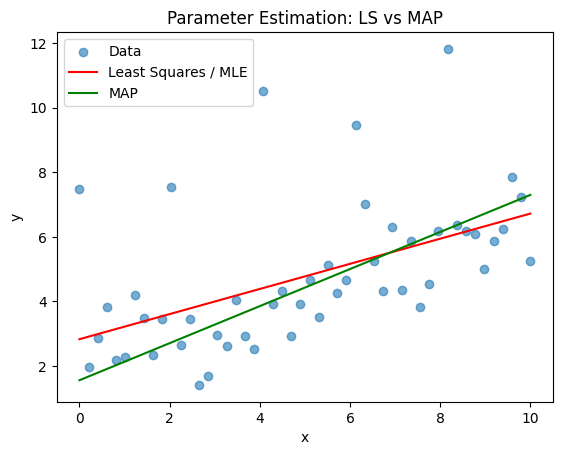

In [6]:
x_plot = np.linspace(0, 10, 100)
X_plot = np.column_stack((np.ones(100), x_plot))

y_ls = X_plot @ beta_ls
y_map = X_plot @ beta_map

plt.scatter(x, y, label="Data", alpha=0.6)
plt.plot(x_plot, y_ls, label="Least Squares / MLE", color="red")
plt.plot(x_plot, y_map, label="MAP", color="green")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parameter Estimation: LS vs MAP")
plt.show()